In [1]:
# Global imports and configuration
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob
import json

from grid_processing import build_new_grid_xesmf, sort_ds

# Environment setup
print(f"Working directory: {os.getcwd()}")
print(f"Python executable: {sys.executable}")
os.environ['HOME'] = '/mnt/disk1/aiotlab/trieutq'

# Global grid parameters
LAT_START, LON_START = 20.027350, 104.790862
STEP_NEW = 0.02780 # ~ 3km
ROWS, COLS = 79, 127
STEP_OLD = 0.1
STEP_FACTOR = (STEP_NEW / STEP_OLD) ** 2
MONTH_FACTOR =  (3000 * 3000) * (30 * 24 * 3600) # for converting from kg/m2/s to kg/3km2/month

# Global paths
BASE_DIR = os.path.expanduser('~/inest/eccad/data/ant2')
OUTPUT_DIR = os.path.join(BASE_DIR, 'json')
NC_DIR = os.path.join(BASE_DIR, 'nc')
DATA_FILE_SUFFIX = "2023.nc"

print(f"Grid parameters: {ROWS}x{COLS}, step={STEP_NEW}")
print(f"Base directory: {BASE_DIR}")




Working directory: /mnt/disk1/aiotlab/trieutq/inest/eccad/handle
Python executable: /mnt/disk1/aiotlab/trieutq/.venv/bin/python
Grid parameters: 79x127, step=0.0278
Base directory: /mnt/disk1/aiotlab/trieutq/inest/eccad/data/ant2


In [ ]:
# Batch process NC files to JSON
os.makedirs(OUTPUT_DIR, exist_ok=True)
nc_files = glob.glob(os.path.join(NC_DIR, '*.nc'))
print(NC_DIR)

def ds_to_json(ds_new: xr.Dataset, max_rows: int = None) -> list[dict]:
    """Convert dataset to JSON format with row/col indices"""
    df = ds_new.to_dataframe().reset_index()

    # Create row/col indices
    lat_vals = df["lat"].unique()
    lon_vals = df["lon"].unique()
    lat_to_row = {v: i for i, v in enumerate(lat_vals)}
    lon_to_col = {v: i for i, v in enumerate(lon_vals)}

    df["row"] = df["lat"].map(lat_to_row)
    df["col"] = df["lon"].map(lon_to_col)

    dfvalue = None
    units = None
    if "sum" in df.columns:
        dfvalue = df["sum"]
        units = df["sum"].attrs["units"]
    elif "emiss_bb" in df.columns:
        dfvalue = df["emiss_bb"]
        units = df["emiss_bb"].attrs["units"]
    elif "emiss_bio" in df.columns:
        dfvalue = df["emiss_bio"]
        units = df["emiss_bio"].attrs["units"]
    elif "all_sources" in df.columns:
        dfvalue = df["all_sources"]
        units = df["all_sources"].attrs["units"]
    else:
        print(df)
        raise ValueError("Dataset does not contain required variables.")

    if units == "Tg":
        df["value"] = dfvalue * STEP_FACTOR * 1e12 # convert Tg to g
    elif units == "kg m-2 s-1":
        df["value"] = dfvalue * MONTH_FACTOR * 1000 # convert kg/m2/s to g
    else:
        raise ValueError("Unknown units.")

    # Reorder columns
    df["time"] = df["time"].dt.strftime("%Y-%m-%d")

    df = df[["time", "row", "col", "lat", "lon", "value"]]

    if max_rows:
        df = df.iloc[:max_rows]

    return df.to_dict(orient="records")

for nc_file in nc_files:
    if not nc_file.endswith(DATA_FILE_SUFFIX):
        continue

    print(f"Processing {os.path.basename(nc_file)}")

    # Load and process dataset
    ds = sort_ds(xr.open_dataset(nc_file))
    ds_new = build_new_grid_xesmf(ds, lat_start=LAT_START, lon_start=LON_START, rows=ROWS, cols=COLS, step=STEP_NEW)
    json_data = ds_to_json(ds_new)

    # Save JSON
    json_filename = os.path.splitext(os.path.basename(nc_file))[0] + '.json'
    json_path = os.path.join(OUTPUT_DIR, json_filename)

    with open(json_path, "w") as f:
        json.dump(json_data, f)

    print(f"Saved {json_path}")

/mnt/disk1/aiotlab/trieutq/inest/eccad/data/ant2/nc
Processing CAMS-GLOB-ANT_Glb_0.1x0.1_anthro_alcohols_v5.3_monthly_2023.nc
Saved /mnt/disk1/aiotlab/trieutq/inest/eccad/data/ant2/json/CAMS-GLOB-ANT_Glb_0.1x0.1_anthro_alcohols_v5.3_monthly_2023.json
Processing CAMS-GLOB-ANT_Glb_0.1x0.1_anthro_ch4_v5.3_monthly_2023.nc


KeyboardInterrupt: 

In [27]:
# Visualization comparison
sample_file = "~/inest/eccad/data/gfed4/nc/GFED4_Glb_0.25x0.25_bb_BC__daily_2022.nc"
sample_file = "~/inest/eccad/handle/resources/qfed2.emis_acet.061.20230101.nc4"
sample_file = "~/inest/eccad/data/bio2/nc/CAMS-GLOB-BIO_Glb_0.25x0.25_bio_acetaldehyde_v3.1_monthly_2023.nc"
sample_file = "~/inest/eccad/data/ant2/nc/CAMS-GLOB-ANT_Glb_0.1x0.1_anthro_bc_v5.3_monthly_2023.nc"
sample_file = "/mnt/disk1/aiotlab/trieutq/inest/eccad/data/bio2/nc/CAMS-GLOB-BIO_Glb_0.25x0.25_bio_propane_v3.1_monthly_2023.nc"
sample_file = "/mnt/disk1/aiotlab/trieutq/inest/eccad/data/bio2/nc/CAMS-GLOB-BIO_Glb_0.25x0.25_bio_isoprene_v3.1_monthly_2023.nc"
ds = sort_ds(xr.open_dataset(sample_file))
print("Original dataset:")
print(ds)


Original dataset:
<xarray.Dataset> Size: 100MB
Dimensions:           (time: 12, lat: 720, lon: 1440)
Coordinates:
  * lat               (lat) float32 3kB -90.0 -89.75 -89.5 ... 89.25 89.5 89.75
  * lon               (lon) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time              (time) datetime64[ns] 96B 2023-01-01 ... 2023-12-01
Data variables:
    emiss_bio         (time, lat, lon) float32 50MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    emiss_bio_hourly  (time, lat, lon) float32 50MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    gridcell_area     (lat) float32 3kB 1.686 5.058 8.429 ... 8.429 5.058 1.686
Attributes:
    name:                      MEGANv2.10 biogenic emissions - SSRD
    metfile:                   ERA5  met data on 025x025 grid
    projection:                latlon          
    nco_openmp_thread_number:  1
    NCO:                       netCDF Operators version 5.1.4 (Homepage = htt...
    source:                    Driving variables are: landcover, weather, and...
    references

In [6]:

nc_files = glob.glob(os.path.join("/mnt/disk1/aiotlab/trieutq/inest/eccad/data/qfed/nc", '*.nc4'))
for nc_file in nc_files:
    ds = xr.open_dataset(nc_file)
    print(ds)
    print(ds["biomass"].attrs["units"], nc_file)
    break


<xarray.Dataset> Size: 130MB
Dimensions:     (lon: 3600, lat: 1800, time: 1)
Coordinates:
  * lon         (lon) float64 29kB -179.9 -179.9 -179.8 ... 179.8 179.9 179.9
  * lat         (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * time        (time) datetime64[ns] 8B 2023-08-27T12:00:00
Data variables:
    biomass     (time, lat, lon) float32 26MB ...
    biomass_tf  (time, lat, lon) float32 26MB ...
    biomass_xf  (time, lat, lon) float32 26MB ...
    biomass_sv  (time, lat, lon) float32 26MB ...
    biomass_gl  (time, lat, lon) float32 26MB ...
Attributes:
    Conventions:  COARDS
    Source:       NASA/GSFC/GMAO GEOS-5 Aerosol Group
    Title:        QFED Level3b v2.5 (@CVSTAG) Gridded Emission Estimates
    Contact:      arlindo.dasilva@nasa.gov
    History:      File written by GFIO v1.0.8
kg s-1 m-2 /mnt/disk1/aiotlab/trieutq/inest/eccad/data/qfed/nc/qfed2.emis_co2.061.20230827.nc4


In [10]:
ds_new = build_new_grid_xesmf(ds, lat_start=LAT_START, lon_start=LON_START, rows=ROWS, cols=COLS, step=STEP_NEW, method="conservative")
print("\nNew grid dataset:")
print(ds_new)


New grid dataset:
<xarray.Dataset> Size: 6MB
Dimensions:  (time: 12, lat: 79, lon: 127)
Coordinates:
  * time     (time) datetime64[ns] 96B 2023-01-01 2023-02-01 ... 2023-12-01
  * lat      (lat) float64 632B 20.03 20.06 20.08 20.11 ... 22.14 22.17 22.2
  * lon      (lon) float64 1kB 104.8 104.8 104.8 104.9 ... 108.2 108.3 108.3
Data variables:
    awb      (time, lat, lon) float32 482kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ene      (time, lat, lon) float32 482kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    fef      (time, lat, lon) float32 482kB 0.0 0.0 0.0 ... 4.233e-11 3.801e-11
    ind      (time, lat, lon) float32 482kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ref      (time, lat, lon) float32 482kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    res      (time, lat, lon) float32 482kB 1.135e-07 1.062e-07 ... 7.876e-07
    shp      (time, lat, lon) float32 482kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    slv      (time, lat, lon) float32 482kB 9.221e-11 8.761e-11 ... 1.05e-08
    sum      (tim

[-89.95 -89.85 -89.75] [89.75 89.85 89.95]
Requested box: lat (21, 22) lon (107, 108)
Dataset ranges: lat (89.94999694824219, -89.94999694824219) lon (-179.9499969482422, 179.9499969482422)


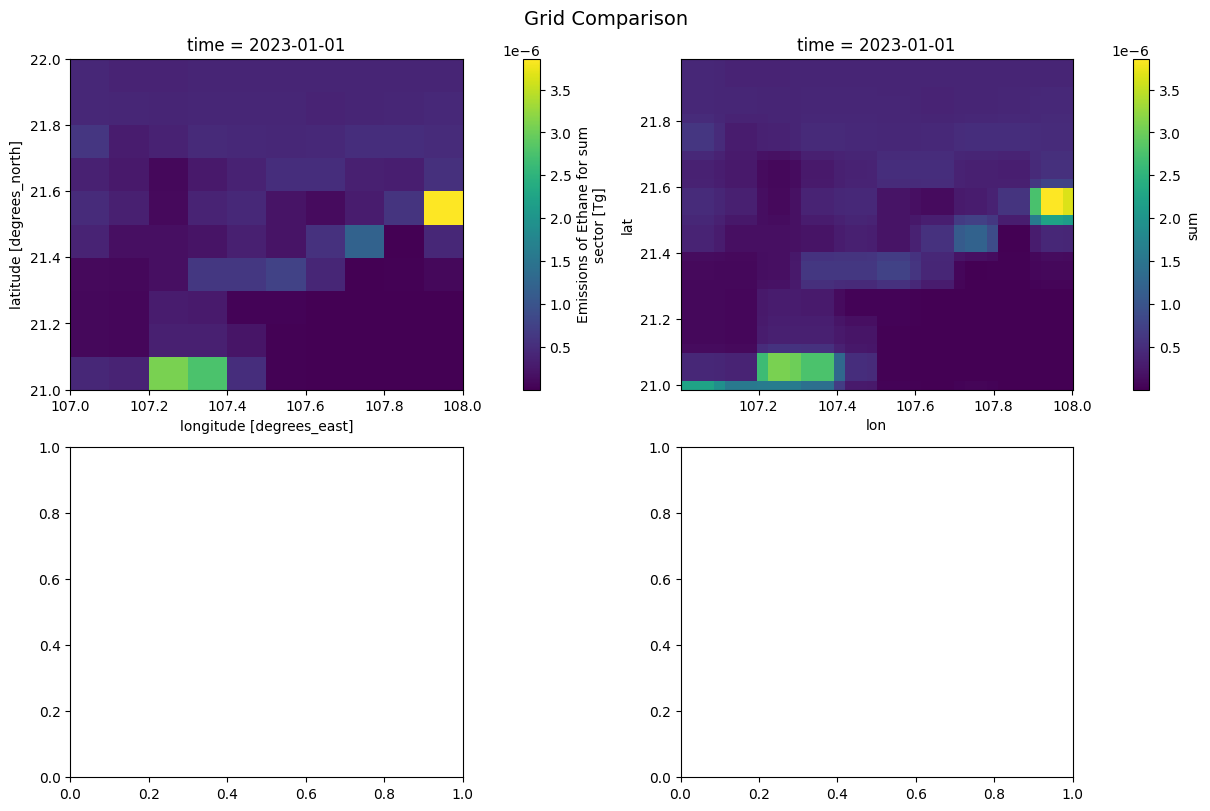

In [12]:
# Visualization
LAT_MIN, LAT_MAX = 21, 22
LON_MIN, LON_MAX = 107, 108
var = "sum"

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

print(ds.lat.values[:3], ds.lat.values[-3:])  # xem chiều lat
print("Requested box:",
      "lat", (LAT_MIN, LAT_MAX), "lon", (LON_MIN, LON_MAX))
print("Dataset ranges:",
      "lat", (float(ds.lat.max()), float(ds.lat.min())),
      "lon", (float(ds.lon.min()), float(ds.lon.max())))

# Cut to region of interest
ds_cut = ds.sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
ds_cut[var].isel(time=0).plot.imshow(
    ax=axes[0], add_colorbar=True, cmap="viridis"
)

# New grid
ds_new_cut = ds_new.sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
ds_new_cut[var].isel(time=0).plot.imshow(
    ax=axes[1], add_colorbar=True, cmap="viridis"
)



plt.suptitle("Grid Comparison", fontsize=14)
plt.show()

In [11]:
# Hiển thị dữ liệu lưới trên bản đồ OpenStreetMap với folium
import folium
from folium.plugins import HeatMap

# Chuyển dữ liệu thành DataFrame
df = ds_new_cut['sum'].isel(time=0).to_dataframe().reset_index()

# Tạo bản đồ trung tâm vùng quan tâm
center_lat = (LAT_MIN + LAT_MAX) / 2
center_lon = (LON_MIN + LON_MAX) / 2
m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

# Tạo danh sách điểm heatmap: [lat, lon, value]
heat_data = [[row['lat'], row['lon'], row['sum']] for _, row in df.iterrows() if not np.isnan(row['sum'])]

HeatMap(heat_data, radius=8, blur=15, max_zoom=1).add_to(m)

# Hiển thị bản đồ
m

KeyError: "No variable named 'sum'. Variables on the dataset include ['time', 'agri', 'all_sources', 'borf', 'defo', ..., 'peat', 'sava', 'temf', 'lat', 'lon']"